## Notebook to reproduce Fig 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

In [3]:
from seaborn.palettes import SEABORN_PALETTES
colorblind = SEABORN_PALETTES["colorblind"]

In [4]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Roman"
})

# Read in data

Load in csv file

In [5]:
match_data_1 = pd.read_csv('../Results/MatchResults_HighSpin.csv')  

In [6]:
match_data_1

,Simulation ID,inclinations,Match (PhenomXPHM),Match (PhenomXO4a),Match (PhenomTPHM),Match (SEOBNRv5PHM),Match (NRSur7dq4)
0,SXS_BBH_0624_Res3,0.000000,0.986909,0.996290,0.982980,0.986622,0.998679
1,SXS_BBH_0624_Res3,0.643501,0.988101,0.994709,0.989459,0.992300,0.998717
2,SXS_BBH_0624_Res3,0.927295,0.989028,0.993886,0.993439,0.994848,0.998828
3,SXS_BBH_0624_Res3,1.159279,0.990711,0.992931,0.995860,0.995991,0.998908
4,SXS_BBH_0624_Res3,1.369438,0.993173,0.992649,0.996513,0.996308,0.998929
...,...,...,...,...,...,...,...
583,SXS_BBH_4079_Res4,0.643501,0.986747,0.981521,0.993737,0.994896,0.997450
584,SXS_BBH_4079_Res4,0.927295,0.981153,0.975459,0.993261,0.993615,0.997652
585,SXS_BBH_4079_Res4,1.159279,0.976700,0.974735,0.990982,0.992441,0.997877
586,SXS_BBH_4079_Res4,1.369438,0.973568,0.975986,0.988251,0.991078,0.997769


In [9]:
match_data_2 = pd.read_csv('../Results/MatchResults_LowSpin.csv')  

In [10]:
match_data_2

,Simulation ID,inclinations,Match (PhenomXPHM),Match (PhenomXO4a),Match (PhenomTPHM),Match (SEOBNRv5PHM),Match (NRSur7dq4)
0,BAM_BBH_CF_21,0.000000,0.999870,0.999951,0.999855,0.999911,0.999962
1,BAM_BBH_CF_21,0.643501,0.999688,0.999313,0.999570,0.999858,0.999949
2,BAM_BBH_CF_21,0.927295,0.999662,0.998848,0.998639,0.999761,0.999934
3,BAM_BBH_CF_21,1.159279,0.999503,0.998419,0.997165,0.999648,0.999911
4,BAM_BBH_CF_21,1.369438,0.998991,0.997399,0.995701,0.999534,0.999876
...,...,...,...,...,...,...,...
6145,SXS_BBH_1080_Res3,0.643501,0.996886,0.998008,0.997237,0.997995,0.999728
6146,SXS_BBH_1080_Res3,0.927295,0.997262,0.997535,0.997004,0.998560,0.999599
6147,SXS_BBH_1080_Res3,1.159279,0.997073,0.996838,0.996599,0.998772,0.999598
6148,SXS_BBH_1080_Res3,1.369438,0.996565,0.996135,0.996277,0.998602,0.999536


Convert to dictionary

In [11]:
match_data_1 = match_data_1.to_dict(orient='list')

In [12]:
match_data_2 = match_data_2.to_dict(orient='list')

Extract mismatch values

In [13]:
MM1 = {}

MM1['XPHM'] = 1. - np.array(match_data_1['Match (PhenomXPHM)'])
MM1['XO4a'] = 1. - np.array(match_data_1['Match (PhenomXO4a)'])
MM1['TPHM'] = 1. - np.array(match_data_1['Match (PhenomTPHM)'])
MM1['v5PHM'] = 1. - np.array(match_data_1['Match (SEOBNRv5PHM)'])
MM1['NRSur'] = 1. - np.array(match_data_1['Match (NRSur7dq4)'])

In [14]:
MM2 = {}

MM2['XPHM'] = 1. - np.array(match_data_2['Match (PhenomXPHM)'])
MM2['XO4a'] = 1. - np.array(match_data_2['Match (PhenomXO4a)'])
MM2['TPHM'] = 1. - np.array(match_data_2['Match (PhenomTPHM)'])
MM2['v5PHM'] = 1. - np.array(match_data_2['Match (SEOBNRv5PHM)'])
MM2['NRSur'] = 1. - np.array(match_data_2['Match (NRSur7dq4)'])

# Plot histogram

In [15]:
color_dict = {
    "NRSur": colorblind[2],
    "XPHM": colorblind[1],
    "TPHM": colorblind[4],
    "v5PHM": colorblind[0],
    "XO4a": colorblind[7],
}

In [16]:
params = { 'xtick.labelsize' : 22.0,
           'ytick.labelsize' : 22.0,
           'axes.labelsize' : 24.0,
           'axes.titlesize' : 24.0,
           'legend.fontsize' : 22.0
         }

In [17]:
plt.rcParams.update(params)

In [18]:
# conservative distinguishability criterion
dc = 0.0028

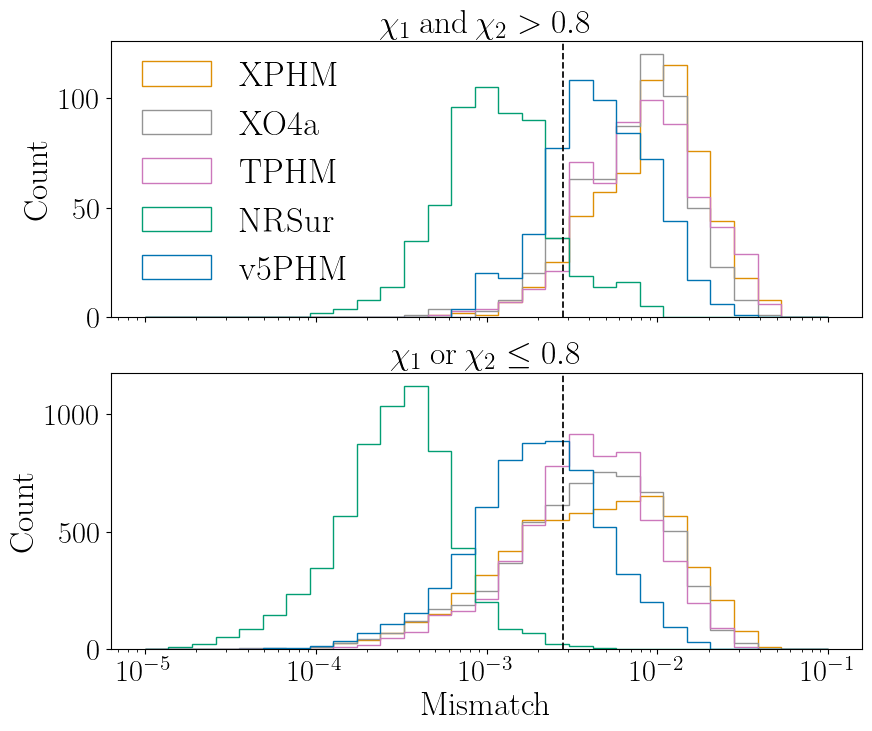

In [20]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9.7, 7.9))

ax1.hist( MM1['XPHM'], bins=np.logspace(np.log10(1e-5),np.log10(0.1),30), histtype='step', color=color_dict['XPHM'], label='XPHM' )
ax1.hist( MM1['XO4a'], bins=np.logspace(np.log10(1e-5),np.log10(0.1),30), histtype='step', color=color_dict['XO4a'], label='XO4a' )
ax1.hist( MM1['TPHM'], bins=np.logspace(np.log10(1e-5),np.log10(0.1),30), histtype='step', color=color_dict['TPHM'], label='TPHM' )
ax1.hist( MM1['NRSur'], bins=np.logspace(np.log10(1e-5),np.log10(0.1),30), histtype='step', color=color_dict['NRSur'], label='NRSur' )
ax1.hist( MM1['v5PHM'], bins=np.logspace(np.log10(1e-5),np.log10(0.1),30), histtype='step', color=color_dict['v5PHM'], label='v5PHM' )

ax2.hist( MM2['XPHM'], bins=np.logspace(np.log10(1e-5),np.log10(0.1),30), histtype='step', color=color_dict['XPHM'] )
ax2.hist( MM2['XO4a'], bins=np.logspace(np.log10(1e-5),np.log10(0.1),30), histtype='step', color=color_dict['XO4a'] )
ax2.hist( MM2['TPHM'], bins=np.logspace(np.log10(1e-5),np.log10(0.1),30), histtype='step', color=color_dict['TPHM'] )
ax2.hist( MM2['NRSur'], bins=np.logspace(np.log10(1e-5),np.log10(0.1),30), histtype='step', color=color_dict['NRSur'] )
ax2.hist( MM2['v5PHM'], bins=np.logspace(np.log10(1e-5),np.log10(0.1),30), histtype='step', color=color_dict['v5PHM'] )

ax1.axvline(dc, c='k', ls='--', lw=1.25)
ax2.axvline(dc, c='k', ls='--', lw=1.25)

ax1.set_xscale('log')
ax2.set_xscale('log')

ax2.set_xlabel('Mismatch')

ax1.set_ylabel('Count')
ax2.set_ylabel('Count')

ax1.set_title('$\\chi_1 \: \\mathrm{and} \: \\chi_2 > 0.8$')
ax2.set_title('$\\chi_1 \: \\mathrm{or} \: \\chi_2 \\le 0.8$')

ax1.legend(loc='best', frameon=False, fontsize=25)

plt.savefig( '../Figures/mismatch-histogram.pdf', pad_inches=0.025, bbox_inches='tight' )

plt.show()   